In [1]:
%matplotlib inline
import numpy as np, pandas as pd, torch, torch.nn as nn, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
np.random.seed(0); torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.12.0+cpu


In [2]:
BASES = "ACGT"; IDX = {b:i for i,b in enumerate(BASES)}
def one_hot(s):
    m = np.zeros((4,len(s)),np.float32)
    for j,b in enumerate(s): m[IDX[b],j]=1
    return m

SEQ_LEN, MOTIF, N = 200, "CCGCGNGGNGGCAG", 2000
rand = lambda L: "".join(np.random.choice(list(BASES),L))
inst = lambda m: "".join(np.random.choice(list(BASES)) if b=="N" else b for b in m)
X, y = [], []
for _ in range(N):
    s=list(rand(SEQ_LEN)); m=inst(MOTIF); p=np.random.randint(0,SEQ_LEN-len(m))
    s[p:p+len(m)]=list(m); X.append("".join(s)); y.append(1)
for _ in range(N):
    X.append(rand(SEQ_LEN)); y.append(0)
Xoh = np.stack([one_hot(s) for s in X]); y = np.array(y,np.float32)
print("X:", Xoh.shape, "| pos:", int(y.sum()), "neg:", int((y==0).sum()))

X: (4000, 4, 200) | pos: 2000 neg: 2000


In [3]:
perm = np.random.permutation(len(y)); Xoh, ys = Xoh[perm], y[perm]
n = int(0.8*len(ys))
Xtr, Xte, ytr, yte = Xoh[:n], Xoh[n:], ys[:n], ys[n:]
print("train:", Xtr.shape, "| test:", Xte.shape)

train: (3200, 4, 200) | test: (800, 4, 200)


In [4]:
class CNN(nn.Module):
    def __init__(s):
        super().__init__(); s.c=nn.Conv1d(4,16,15); s.f=nn.Linear(16,1)
    def forward(s,x):
        return s.f(torch.relu(s.c(x)).max(2).values)
model = CNN(); opt = torch.optim.Adam(model.parameters(),1e-3); lf = nn.BCEWithLogitsLoss()
print("params:", sum(p.numel() for p in model.parameters()))

params: 993


In [5]:
Xt, yt = torch.tensor(Xtr), torch.tensor(ytr).unsqueeze(1)
hist = []
for e in range(15):
    o = torch.randperm(len(Xt)); tot = 0.0
    for i in range(0,len(Xt),128):
        j = o[i:i+128]; opt.zero_grad(); L = lf(model(Xt[j]),yt[j]); L.backward(); opt.step()
        tot += L.item()*len(j)
    hist.append(tot/len(Xt)); print(f"epoch {e+1:2d}/15  loss {hist[-1]:.4f}")

epoch  1/15  loss 0.6932
epoch  2/15  loss 0.6793


epoch  3/15  loss 0.6572
epoch  4/15  loss 0.6282


epoch  5/15  loss 0.5891
epoch  6/15  loss 0.5400


epoch  7/15  loss 0.4842
epoch  8/15  loss 0.4248


epoch  9/15  loss 0.3656
epoch 10/15  loss 0.3095
epoch 11/15  loss 0.2615


epoch 12/15  loss 0.2205
epoch 13/15  loss 0.1878


epoch 14/15  loss 0.1598
epoch 15/15  loss 0.1377


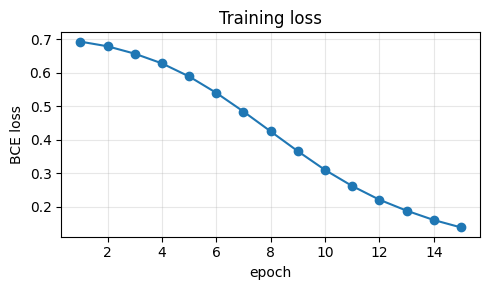

In [6]:
plt.figure(figsize=(5,3)); plt.plot(range(1,16),hist,marker="o")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Training loss"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

accuracy: 0.993 | ROC-AUC: 1.0


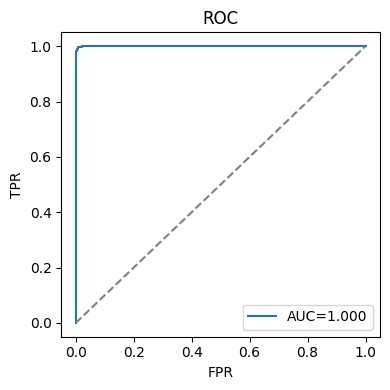

In [7]:
with torch.no_grad(): p = torch.sigmoid(model(torch.tensor(Xte))).numpy().ravel()
print("accuracy:", round(float(((p>.5)==yte).mean()),3), "| ROC-AUC:", round(float(roc_auc_score(yte,p)),3))
fpr,tpr,_ = roc_curve(yte,p)
plt.figure(figsize=(4,4)); plt.plot(fpr,tpr,label=f"AUC={roc_auc_score(yte,p):.3f}")
plt.plot([0,1],[0,1],"--",color="gray"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC"); plt.legend(); plt.tight_layout(); plt.show()

In [8]:
seq = Xte[np.where(yte==1)[0][0]]; ref = "".join(BASES[i] for i in seq.argmax(0))
def prob(m):
    with torch.no_grad(): return torch.sigmoid(model(torch.tensor(m[None]))).item()
r0 = prob(one_hot(ref)); D = np.zeros((4,SEQ_LEN),np.float32)
for j in range(SEQ_LEN):
    for b in range(4):
        mut = one_hot(ref).copy(); mut[:,j]=0; mut[b,j]=1; D[b,j] = prob(mut)-r0
print("reference P(bound):", round(r0,3))

reference P(bound): 0.719


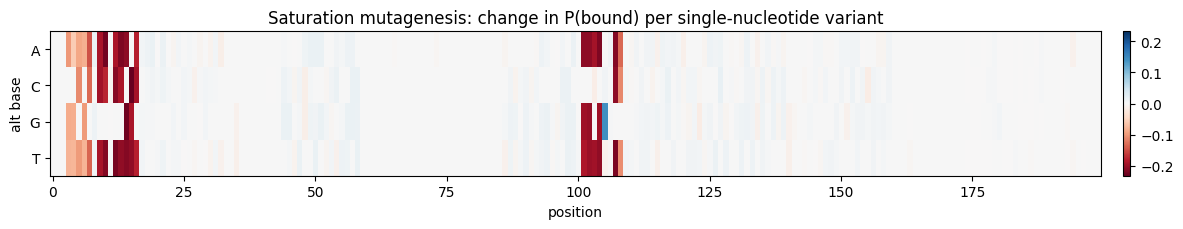

In [9]:
v = max(abs(D).max(),1e-6)
plt.figure(figsize=(12,2.4))
im = plt.imshow(D,aspect="auto",cmap="RdBu",vmin=-v,vmax=v)
plt.yticks(range(4),list(BASES)); plt.xlabel("position"); plt.ylabel("alt base")
plt.title("Saturation mutagenesis: change in P(bound) per single-nucleotide variant")
plt.colorbar(im,fraction=0.025,pad=0.02); plt.tight_layout(); plt.show()

In [10]:
ri = one_hot(ref).argmax(0)
df = pd.DataFrame([{"pos":j,"ref":BASES[ri[j]],"alt":BASES[b],"dscore":float(D[b,j])}
                   for j in range(SEQ_LEN) for b in range(4) if b!=ri[j]])
df["abs"] = df["dscore"].abs()
df.sort_values("abs",ascending=False).drop(columns="abs").head(10).reset_index(drop=True)

,pos,ref,alt,dscore
0,15,A,C,-0.232504
1,14,C,G,-0.226132
2,10,G,A,-0.223426
3,12,G,T,-0.220486
4,107,G,T,-0.218485
5,13,G,A,-0.216855
6,104,C,A,-0.216160
7,10,G,T,-0.214115
8,14,C,T,-0.213819
9,107,G,A,-0.213676
